## Term Deposit Subscription Prediction
### Objective:
To build a machine learning model that predicts whether a customer will subscribe to a term deposit after a marketing campaign and to interpret the model using SHAP (SHapley Additive Explanations).

### Step # 2: Import Libraries

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
# SHAP for explainability
import shap

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
# Train Test Split
from sklearn.model_selection import train_test_split

### Step # 3 Load Data

In [8]:
# Load dataset
df = pd.read_csv("bank.csv")

In [9]:
# Show first rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### step # 4. DATA PREPROCESSING

In [10]:
df.shape

(11162, 17)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [13]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

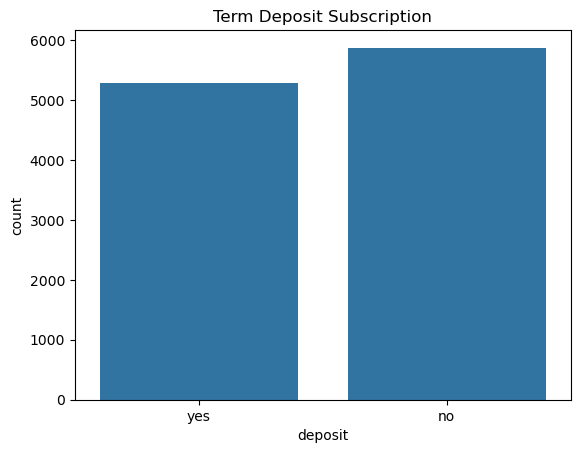

In [14]:
sns.countplot(x='deposit', data=df)

plt.title("Term Deposit Subscription")

plt.show()

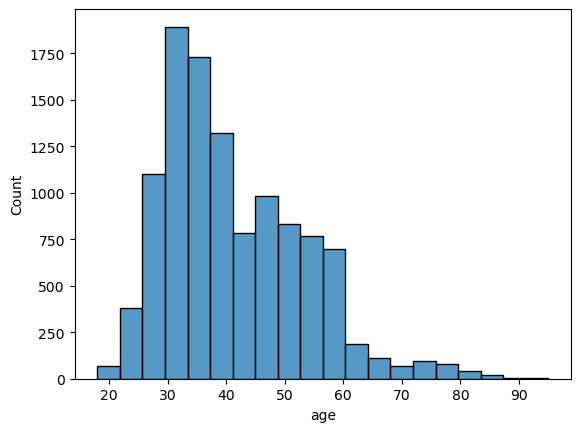

In [15]:
sns.histplot(df['age'], bins=20)

plt.show()

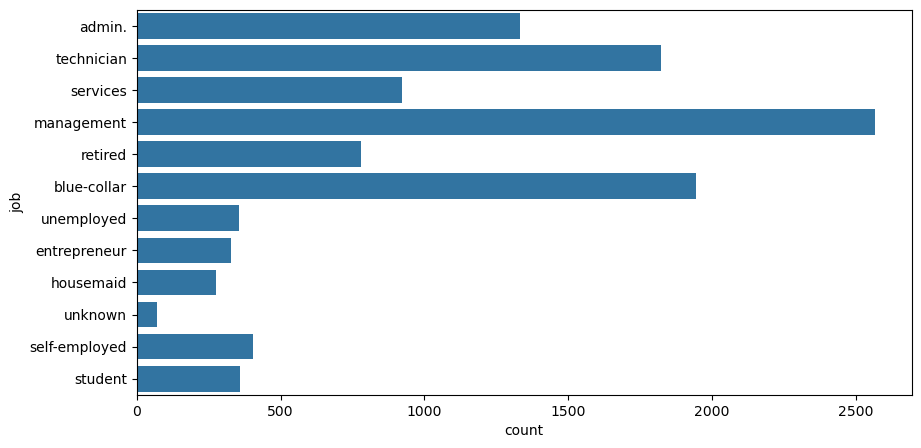

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='job',
    data=df
)
plt.show()

In [21]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

In [22]:
X = df.drop('deposit', axis=1)

y = df['deposit']

### 5. TRAIN TEST SPLIT

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test =  train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

### Step # 6. MODEL TRAINING

In [24]:
# Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)

### step # 7. MODEL PREDICTION & ACCURACY

In [ ]:
# Predictions
y_pred = rf.predict(X_test)

# Accuracy check
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

### Step # 8 Shap Explainability steup

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# Get SHAP values
shap_values = explainer(X_test)

# JS visualization (for notebook)
shap.initjs()

### step # 9. GLOBAL EXPLANATION (SUMMARY PLOT)

In [ ]:
# Feature importance overview
shap.summary_plot(shap_values, X_test)|

### Step # 10. LOCAL EXPLANATION (FORCE PLOT)

In [ ]:
# Explain individual predictions (first 5 customers)

for i in range(5):
    shap.plots.force(shap_values[i])

### step # 11. SIMPLE INTERPRETATION (FOR REPORT)

Interpretation:

- SHAP shows how each feature affects the prediction for each customer.
- Positive values push prediction toward "Subscribed".
- Negative values push prediction toward "Not Subscribed".
- Each row represents one customer explanation.

## step # 12. FINAL CONCLUSION

### Conclusion:

A random forest classifier was developed to predict whether a customer would subscribe to a term deposit after a marketing campaign.

The model demonstrated good predictive performance on the test dataset. To improve model interpretability, SHAP (SHapley Additive Explanations) was applied.

The SHAP summary plot identified the most influential features affecting customer subscription decisions, while the force plots provided detailed explanations for individual predictions.

Overall, the combination of Random Forest and SHAP provides both accurate predictions and transparent insights, helping businesses better understand customer behaviour and improve future marketing strategies.